# Price Elasticity and Revenue Optimization

Business question: how sensitive is demand to price, and where is the profit-maximizing price for an elastic SKU?
Simulated weekly pricing table with price, promo flags, and quantity sold for two product types.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
%matplotlib inline


In [ ]:
df_sales = pd.read_csv('../data/price_elasticity.csv')
df_sales.head()


,week,price_A,quantity_A,promo_A,price_B,quantity_B,promo_B
0,1,2.22,294,1,13.63,355,1
1,2,1.41,591,0,12.76,333,0
2,3,1.27,615,0,13.87,355,0
3,4,1.63,455,0,19.25,311,1
4,5,1.53,535,0,18.16,306,0


### demand curves
Price and quantity are inspected before fitting the elasticity model.

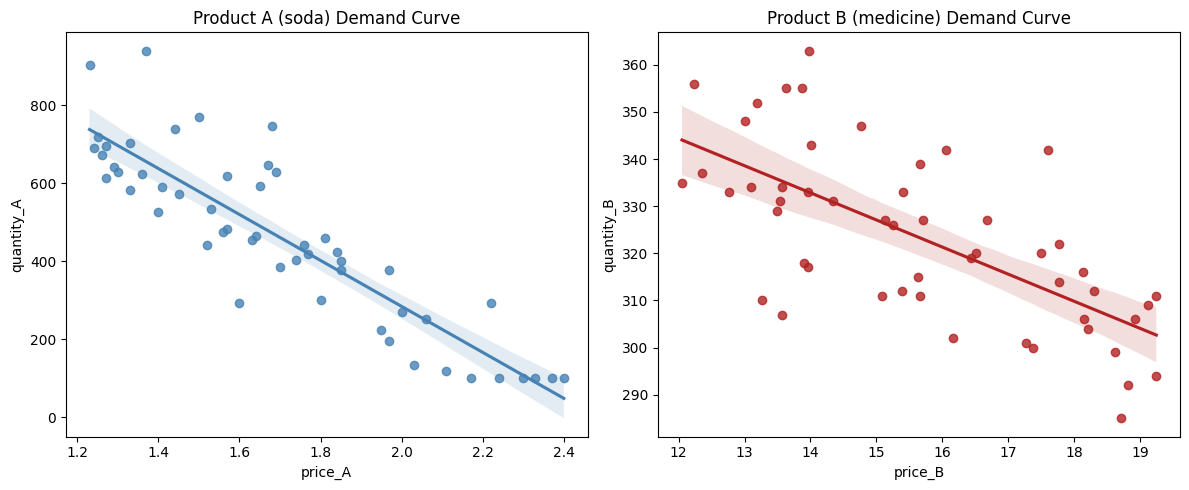

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=df_sales, x='price_A', y='quantity_A', ax=axes[0], color='#4682b4')
axes[0].set_title('Product A (soda) Demand Curve')
sns.regplot(data=df_sales, x='price_B', y='quantity_B', ax=axes[1], color='#b22222')
axes[1].set_title('Product B (medicine) Demand Curve')
plt.tight_layout()
plt.show()


Product A is visibly price-sensitive. Product B has a flatter slope, suggesting inelastic demand.
Log-log regressions estimate: $\ln(Q) = \beta_0 + \beta_1 \ln(P) + \beta_2 \text{promo} + \epsilon$
where $\beta_1$ is the price elasticity coefficient.

In [ ]:
df_sales['log_Q_A'] = np.log(df_sales['quantity_A'])
df_sales['log_P_A'] = np.log(df_sales['price_A'])
df_sales['log_Q_B'] = np.log(df_sales['quantity_B'])
df_sales['log_P_B'] = np.log(df_sales['price_B'])


In [ ]:
model_A = ols('log_Q_A ~ log_P_A + promo_A', data=df_sales).fit()
print("=== PRODUCT A OLS SUMMARY ===")
print(model_A.summary())


=== PRODUCT A OLS SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                log_Q_A   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     139.4
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           5.97e-21
Time:                        01:43:22   Log-Likelihood:                -2.1091
No. Observations:                  52   AIC:                             10.22
Df Residuals:                      49   BIC:                             16.07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3687 

In [ ]:
model_B = ols('log_Q_B ~ log_P_B + promo_B', data=df_sales).fit()
print("=== PRODUCT B OLS SUMMARY ===")
print(model_B.summary())


=== PRODUCT B OLS SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                log_Q_B   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     24.46
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           4.30e-08
Time:                        01:43:22   Log-Likelihood:                 94.171
No. Observations:                  52   AIC:                            -182.3
Df Residuals:                      49   BIC:                            -176.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5336 

### elasticity readout:
- **Product A price elasticity**: coefficient $\beta_1$ should be strongly negative (e.g. < -1.0, signifying elastic demand).
- **Product B price elasticity**: coefficient $\beta_1$ will be closer to 0 (signifying inelastic demand).
For Product A, estimate the profit-maximizing price under elasticity $E$:
$$P_{opt} = MC \times \frac{E}{E + 1}$$
assuming marginal cost (MC) for Product A is $0.60.

In [ ]:
elasticity_A = model_A.params['log_P_A']
intercept_A = model_A.params['Intercept']
mc_A = 0.60

if elasticity_A < -1:
    opt_price_A = mc_A * (elasticity_A / (elasticity_A + 1))
    print(f"estimated elasticity for A: {elasticity_A:.3f}")
    print(f"optimal price for A to maximize profit: ${opt_price_A:.2f} (current avg price: ${df_sales['price_A'].mean():.2f})")
else:
    print("demand is inelastic; pricing is not constrained by elasticity (raise prices to increase revenue)")


estimated elasticity for A: -2.962
optimal price for A to maximize profit: $0.91 (current avg price: $1.70)


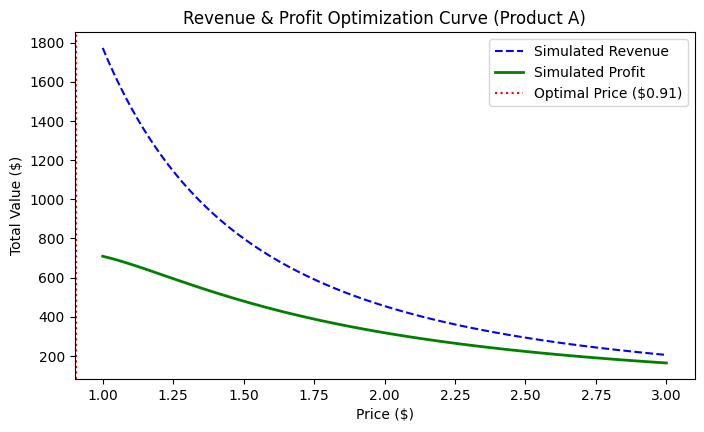

In [ ]:
sim_prices = np.linspace(1.0, 3.0, 100)
avg_promo_A = df_sales['promo_A'].mean()
pred_log_Q = intercept_A + elasticity_A * np.log(sim_prices) + model_A.params['promo_A'] * avg_promo_A
pred_Q = np.exp(pred_log_Q)
sim_revenue = sim_prices * pred_Q
sim_profit = (sim_prices - mc_A) * pred_Q

plt.figure(figsize=(8, 4.5))
plt.plot(sim_prices, sim_revenue, label='Simulated Revenue', color='blue', linestyle='--')
plt.plot(sim_prices, sim_profit, label='Simulated Profit', color='green', linewidth=2)
plt.axvline(opt_price_A, color='red', linestyle=':', label=f'Optimal Price (${opt_price_A:.2f})')
plt.xlabel('Price ($)')
plt.ylabel('Total Value ($)')
plt.title('Revenue & Profit Optimization Curve (Product A)')
plt.legend()
plt.show()
